In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
dataset = pd.read_csv(r"C:\Users\91958\Desktop\Machine Learning\datasets\50_Startups.csv")

dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [4]:
dataset.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [5]:
dataset.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [6]:
print("Rows :", dataset.shape[0])
print("Columns :", dataset.shape[1])

Rows : 50
Columns : 5


In [7]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [8]:
print(X.head())

print()

print(y.head())

   R&D Spend  Administration  Marketing Spend       State
0  165349.20       136897.80        471784.10    New York
1  162597.70       151377.59        443898.53  California
2  153441.51       101145.55        407934.54     Florida
3  144372.41       118671.85        383199.62    New York
4  142107.34        91391.77        366168.42     Florida

0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), ["State"])
    ],
    remainder="passthrough"
)

In [11]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [12]:
model.fit(X_train, y_train)

C:\Users\91958\anaconda3\lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['State'])])),
                ('regressor', LinearRegression())])

In [13]:
y_pred = model.predict(X_test)

In [14]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,134307.35,126362.879083
1,81005.76,84608.453836
2,99937.59,99677.494252
3,64926.08,46357.460686
4,125370.37,128750.482885
5,35673.41,50912.417419
6,105733.54,109741.350327
7,107404.34,100643.242816
8,97427.84,97599.275746
9,122776.86,113097.425244


In [15]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

Mean Squared Error: 82010363.04501392
R² Score: 0.8987266414319833


In [16]:
linear_model = model.named_steps["regressor"]

print("Intercept:", linear_model.intercept_)

Intercept: 54028.03959405855


In [17]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

feature_names

array(['cat__State_Florida', 'cat__State_New York',
       'remainder__R&D Spend', 'remainder__Administration',
       'remainder__Marketing Spend'], dtype=object)

In [18]:
coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,cat__State_Florida,938.793006
1,cat__State_New York,6.987760
2,remainder__R&D Spend,0.805630
3,remainder__Administration,-0.068788
4,remainder__Marketing Spend,0.029855


In [19]:
new_startup = pd.DataFrame({
    "R&D Spend": [150000],
    "Administration": [120000],
    "Marketing Spend": [300000],
    "State": ["New York"]
})

prediction = model.predict(new_startup)

print("Predicted Profit:", prediction[0])

Predicted Profit: 175581.623914534


In [20]:
residuals = y_test - y_pred

residuals.head()

13     7944.470917
39    -3602.693836
30      260.095748
45    18568.619314
17    -3380.112885
Name: Profit, dtype: float64

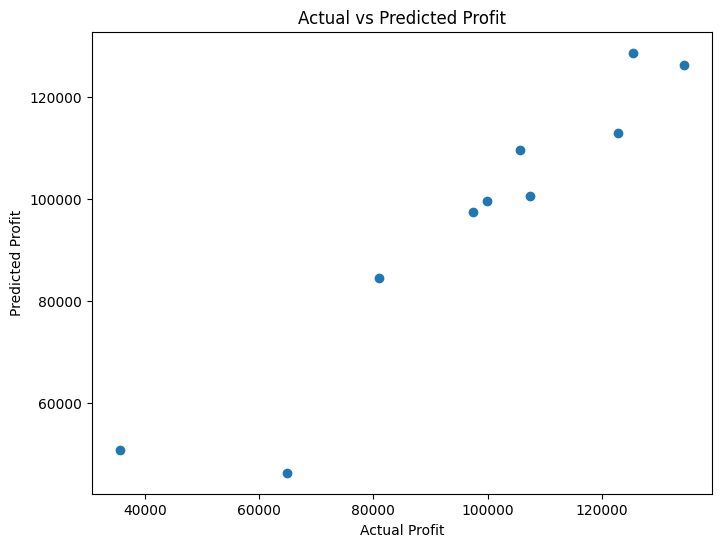

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

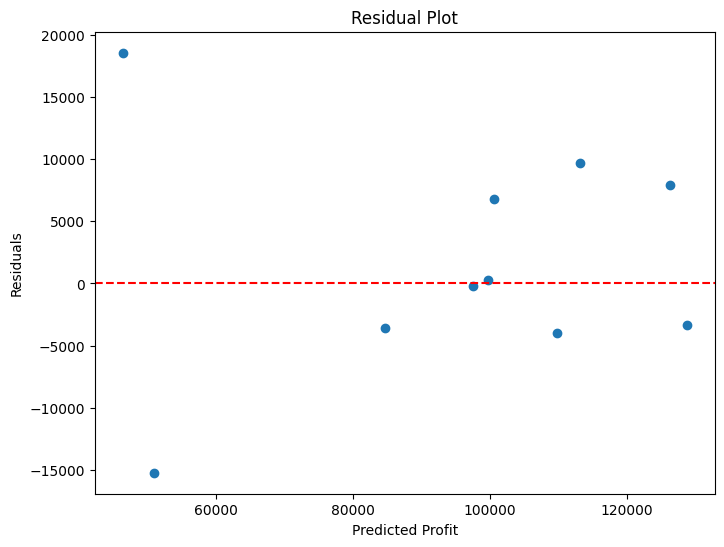

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Profit")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [23]:
print("Training Score :", model.score(X_train, y_train))

print("Testing Score :", model.score(X_test, y_test))

Training Score : 0.9537019995248526
Testing Score : 0.8987266414319833
